<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 65 · Sampling &amp; Data Collection</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Study Design &amp; Data Quality 🧪</div>
  <div style="font-size:15px;color:#fff1f2;max-width:740px;line-height:1.6">How you collect data decides what you can conclude. Experiments establish cause; observation only shows association. We see confounding distort an effect, randomization fix it, Simpson&#39;s paradox flip a conclusion, and the dimensions that make data trustworthy.</div>
  <div style="margin-top:16px;font-size:13px;color:#fecdd3">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROSE="#e11d48"; DEEP="#be123c"; LIGHT="#fb7185"; INK="#1a2138"; GRID="#e6e9f2"; TEAL="#0d9488"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
rng = np.random.default_rng(65)

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 1 · OBSERVATIONAL DATA &amp; CONFOUNDING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Correlation that a lurking variable invented</div>
<div style="color:#4a5578;margin-top:6px">In an observational study we only watch. A confounder, a variable that drives BOTH things, can manufacture a correlation between them. Ice-cream sales and drownings rise together, but neither causes the other: hot weather drives both.</div>
</div>

In [2]:
days = 1000
temp = rng.uniform(40, 100, days)            # the confounder
ice_cream = 50 + 3.0*temp + rng.normal(0,30,days)
drownings = 1 + 0.10*temp + rng.normal(0,2,days)
r_raw = np.corrcoef(ice_cream, drownings)[0,1]
print(f"raw correlation(ice cream, drownings) = {r_raw:.2f}  (looks strong!)")
# control for temperature: correlate the residuals after removing temp
def resid(y): return y - np.poly1d(np.polyfit(temp, y, 1))(temp)
r_ctrl = np.corrcoef(resid(ice_cream), resid(drownings))[0,1]
print(f"correlation after controlling for temperature = {r_ctrl:.2f}  (vanishes)")
print("\nthe link was spurious: temperature is the common cause")

raw correlation(ice cream, drownings) = 0.58  (looks strong!)
correlation after controlling for temperature = -0.03  (vanishes)

the link was spurious: temperature is the common cause


The raw correlation is strong, but once we hold temperature constant it collapses to nearly zero. This is the fatal limit of observational data: a confounder can fake an association, so observation alone can never prove causation.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 2 · RANDOMIZATION FIXES CONFOUNDING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The experiment that balances everything</div>
<div style="color:#4a5578;margin-top:6px">An experiment ASSIGNS the treatment. If people choose their own group, confounders sneak in; if a coin flip assigns them, every confounder, known or unknown, is balanced across groups on average, so the difference in outcomes is the causal effect.</div>
</div>

In [3]:
n=4000
age = rng.uniform(20, 70, n)                 # confounder: age affects the outcome
baseline = 100 - 0.5*age
true_effect = 8.0                            # the real treatment effect
# (a) SELF-SELECTED: older people opt into treatment -> confounded
p_treat = 1/(1+np.exp(-(age-45)/8))
tr_self = rng.random(n) < p_treat
out_self = baseline + true_effect*tr_self + rng.normal(0,5,n)
naive_self = out_self[tr_self].mean() - out_self[~tr_self].mean()
# (b) RANDOMIZED: coin flip assigns treatment
tr_rand = rng.random(n) < 0.5
out_rand = baseline + true_effect*tr_rand + rng.normal(0,5,n)
naive_rand = out_rand[tr_rand].mean() - out_rand[~tr_rand].mean()
print(f"true treatment effect = {true_effect:.1f}")
print(f"observational (self-selected) estimate = {naive_self:+.1f}  -> biased (age confound)")
print(f"randomized experiment estimate         = {naive_rand:+.1f}  -> recovers the truth")
print(f"\nmean age treated vs control: self-selected {age[tr_self].mean():.0f}/{age[~tr_self].mean():.0f}, randomized {age[tr_rand].mean():.0f}/{age[~tr_rand].mean():.0f}")

true treatment effect = 8.0
observational (self-selected) estimate = -1.5  -> biased (age confound)
randomized experiment estimate         = +8.0  -> recovers the truth

mean age treated vs control: self-selected 55/36, randomized 45/45


Self-selection lets age contaminate the estimate: the treated group is older, so the naive comparison is wrong. Randomization makes the groups statistically identical on age (and everything else), so the raw difference is the true causal effect. This is why the randomized controlled trial is the gold standard for causation.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 3 · SIMPSON'S PARADOX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A trend that reverses when you split the data</div>
<div style="color:#4a5578;margin-top:6px">The most startling confounding effect: an association can point one way overall and the OPPOSITE way in every subgroup. We use the real kidney-stone data (Charig et al., 1986): Treatment A vs B for small and large stones.</div>
</div>

In [4]:
data = pd.DataFrame({
  "treatment":["A","A","B","B"],
  "stone":["small","large","small","large"],
  "success":[81,192,234,55],
  "total":[87,263,270,80]})
data["rate"] = data.success/data.total
print(data.to_string(index=False))
overall = data.groupby("treatment").apply(lambda g: g.success.sum()/g.total.sum(), include_groups=False)
print(f"\nOVERALL success: A = {overall['A']:.1%}, B = {overall['B']:.1%}  -> B looks better")
print(f"SMALL stones:   A = {81/87:.1%}, B = {234/270:.1%}  -> A better")
print(f"LARGE stones:   A = {192/263:.1%}, B = {55/80:.1%}  -> A better")
print("\nA wins in BOTH subgroups yet loses overall: stone size is the confounder")

treatment stone  success  total     rate
        A small       81     87 0.931034
        A large      192    263 0.730038
        B small      234    270 0.866667
        B large       55     80 0.687500

OVERALL success: A = 78.0%, B = 82.6%  -> B looks better
SMALL stones:   A = 93.1%, B = 86.7%  -> A better
LARGE stones:   A = 73.0%, B = 68.8%  -> A better

A wins in BOTH subgroups yet loses overall: stone size is the confounder


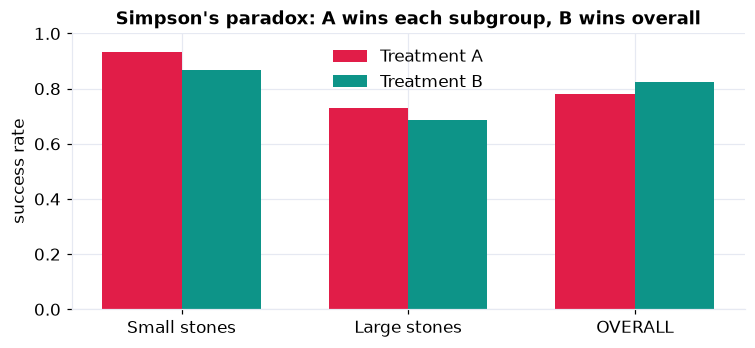

In [5]:
fig,ax=plt.subplots(figsize=(7,3.3))
x=np.arange(3); w=0.35
A=[81/87,192/263,273/350]; B=[234/270,55/80,289/350]
ax.bar(x-w/2,A,w,label="Treatment A",color=ROSE)
ax.bar(x+w/2,B,w,label="Treatment B",color=TEAL)
ax.set_xticks(x); ax.set_xticklabels(["Small stones","Large stones","OVERALL"])
ax.set_ylabel("success rate"); ax.set_ylim(0,1); ax.set_title("Simpson's paradox: A wins each subgroup, B wins overall"); ax.legend()
plt.tight_layout(); plt.show()

Treatment A is better for small stones (93% vs 87%) and for large stones (73% vs 69%), yet B beats A overall (83% vs 78%). The trick is allocation: A was given to far more of the hard (large-stone) cases. Aggregating across a confounder can reverse the truth, so always ask what variable might be hiding in a comparison.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 4 · DATA QUALITY DIMENSIONS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Trust comes from completeness, validity, consistency</div>
<div style="color:#4a5578;margin-top:6px">Even a well-designed study fails on dirty data. We audit a small dataset across the standard quality dimensions and quantify each problem, the checklist every dataset should pass.</div>
</div>

In [6]:
df = pd.DataFrame({
  "id":[1,2,3,3,5,6],                               # duplicate id 3
  "age":[34, 29, np.nan, 41, 200, 52],              # missing + impossible 200
  "height_cm":[170, 165, 180, 180, 1.75, 168],      # 1.75 is meters, wrong unit
  "signup":["2025-01-03","2025-02-11","2025-02-11","bad-date","2025-03-01","2025-03-09"]})
n=len(df)
completeness = 1 - df["age"].isna().mean()
uniqueness   = df["id"].nunique()/n
validity_age = df["age"].between(0,120).mean()
consistency_h= df["height_cm"].between(50,250).mean()
valid_dates  = pd.to_datetime(df["signup"], errors="coerce").notna().mean()
print(f"Completeness (age present)      : {completeness:.0%}")
print(f"Uniqueness (distinct ids)       : {uniqueness:.0%}  (a duplicate row)")
print(f"Validity (age 0-120)            : {validity_age:.0%}  (age=200 impossible)")
print(f"Consistency (height in cm)      : {consistency_h:.0%}  (1.75 is meters)")
print(f"Timeliness/format (valid dates) : {valid_dates:.0%}  (one unparseable date)")

Completeness (age present)      : 83%
Uniqueness (distinct ids)       : 83%  (a duplicate row)
Validity (age 0-120)            : 67%  (age=200 impossible)
Consistency (height in cm)      : 83%  (1.75 is meters)
Timeliness/format (valid dates) : 83%  (one unparseable date)


Each dimension catches a different failure: a missing age (completeness), a duplicated row (uniqueness), an impossible 200-year-old (validity), a height recorded in meters (consistency), a malformed date (format). Quality is multi-dimensional, and a dataset is only as trustworthy as its weakest dimension.

<div style="background:#fff1f2;border-left:5px solid #e11d48;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#be123c;letter-spacing:1px">DEMO 5 · DESIGN BEATS CLEANUP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Garbage in, garbage out</div>
<div style="color:#4a5578;margin-top:6px">No model or test can rescue a badly collected dataset. We re-run the confounded estimate from Demo 2 with TEN TIMES more data: the bias does not shrink, because it is a design flaw, not a sample-size one.</div>
</div>

In [7]:
for n in [4000, 40000]:
    age = rng.uniform(20,70,n); baseline=100-0.5*age
    p = 1/(1+np.exp(-(age-45)/8)); tr = rng.random(n)<p
    out = baseline + 8.0*tr + rng.normal(0,5,n)
    est = out[tr].mean()-out[~tr].mean()
    print(f"observational estimate at n={n:>6}: {est:+.1f}  (true 8.0)")
print("\nten times the data, same wrong answer: only better DESIGN (randomization) fixes it")

observational estimate at n=  4000: -1.1  (true 8.0)
observational estimate at n= 40000: -1.2  (true 8.0)

ten times the data, same wrong answer: only better DESIGN (randomization) fixes it


The confounded estimate is just as wrong with 40,000 rows as with 4,000, because the flaw is in how the data was generated, not how much there is. Good study design and clean data are decisions made <em>before</em> collection; no amount of downstream modeling can substitute for them.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Design first</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Observational studies show association; only randomized experiments establish causation, because randomization balances every confounder. Simpson&#39;s paradox warns that aggregating across a lurking variable can reverse a conclusion. And clean, valid, complete, consistent data is a precondition, not an afterthought: ten times more confounded data is still confounded. Design and quality are decided before a single row is analyzed.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>